In [1]:
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures


It seems Dataset 1 shows a linear relationship, while Dataset 2 appears to show a polynomial relationship.

--- Dataset 1 (Linear) ---
MSE_1: 0.01802
R²_1:  0.99946
coef_1: 2.0030
intercept_1: 3.0564

--- Dataset 2 (Polynomial Degree 2) ---
MSE_2: 1.34130
R²_2:  0.98071
coef_2: [ 1.84818182 -0.66048951]
intercept_2: 4.2958

--- Dataset 2 Adjusted R²---
Degree  2 | R² = 0.9807 | Adjusted R² = 0.9759
Degree  5 | R² = 0.9895 | Adjusted R² = 0.9789
Degree  8 | R² = 0.9980 | Adjusted R² = 0.9900
Degree 10 | R² = 1.0000 | Adjusted R² = Undefined (df <= 0)

--- Question 5 Predictions ---
Dataset 1 prediction for 4.5 hours: 12.0700 kg
Dataset 2 prediction for 0.5 kg load: 5.0548 score


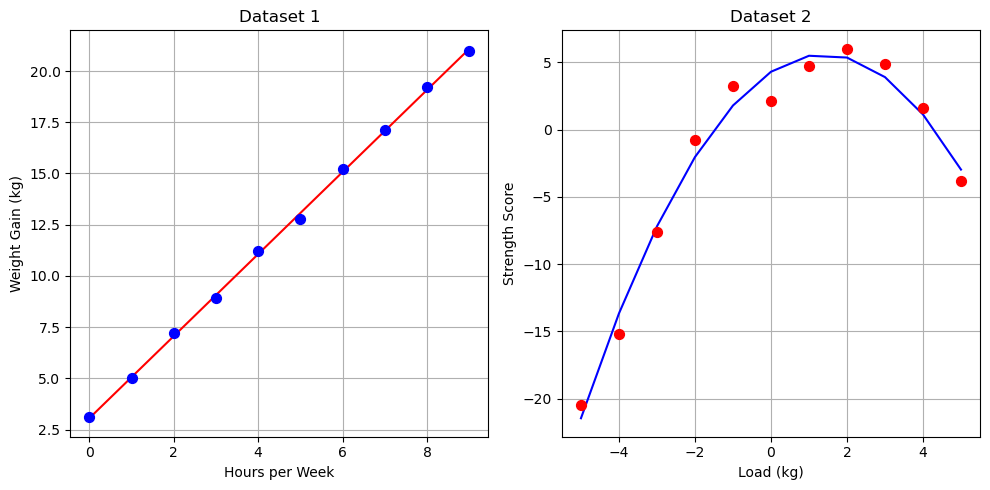

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures

# ==========================================
# Data Setup
# ==========================================
hours_week = np.arange(0, 9 + 1).reshape(-1, 1)
gain_kg = np.array([3.1, 5.0, 7.2, 8.9, 11.2, 12.8, 15.2, 17.1, 19.2, 21.0])

load_kg = np.arange(-5, 5 +1).reshape(-1, 1)
strength_score = np.array([-20.5, -15.2, -7.6, -0.8, 3.2, 2.1, 4.7, 6.0, 4.9, 1.6, -3.8])

# ==========================================
# Question 1: Visual Inspection Plot
# Plot the data (scatter plot) for each dataset and decide visually what kind of pattern it shows
# ==========================================
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

axes[0].scatter(hours_week, gain_kg, color="blue", zorder=5, s=50)
axes[0].set_title("Dataset 1")
axes[0].set_xlabel("Hours per Week")
axes[0].set_ylabel("Weight Gain (kg)")
axes[0].grid(True)

axes[1].scatter(load_kg, strength_score, color="red", zorder=5, s=50)
axes[1].set_title("Dataset 2")
axes[1].set_xlabel("Load (kg)")
axes[1].set_ylabel("Strength Score")
axes[1].grid(True)

plt.tight_layout()
print('\nIt seems Dataset 1 shows a linear relationship, while Dataset 2 appears to show a polynomial relationship.\n')

# ==========================================
# Question 2 & 3: Model Fitting & Metrics
# choose model type If the pattern looks linear, fit LinearRegression. If it looks curved, fit Polynomial Regression with degree 2
# metrics For both models, calculate and print MSE and R²
# ==========================================
# Model 1: Linear
model1 = LinearRegression()
model1.fit(hours_week, gain_kg)
y_pred_1 = model1.predict(hours_week)

mse_1 = mean_squared_error(gain_kg, y_pred_1)
R2_1 = r2_score(gain_kg, y_pred_1)

print("--- Dataset 1 (Linear) ---")
print(f"MSE_1: {mse_1:.5f}")
print(f"R²_1:  {R2_1:.5f}")
print(f"coef_1: {model1.coef_[0]:.4f}")
print(f"intercept_1: {model1.intercept_:.4f}\n")

axes[0].plot(hours_week, y_pred_1, color="red")

# Model 2: Polynomial (Degree 2)
poly_deg2 = PolynomialFeatures(degree=2, include_bias=False)
X_poly2 = poly_deg2.fit_transform(load_kg)

model2 = LinearRegression()
model2.fit(X_poly2, strength_score)
y_pred_2 = model2.predict(X_poly2)

mse_2 = mean_squared_error(strength_score, y_pred_2)
R2_2 = r2_score(strength_score, y_pred_2)

print("--- Dataset 2 (Polynomial Degree 2) ---")
print(f"MSE_2: {mse_2:.5f}")
print(f"R²_2:  {R2_2:.5f}")
print(f"coef_2: {model2.coef_}")
print(f"intercept_2: {model2.intercept_:.4f}\n")

axes[1].plot(load_kg, y_pred_2, color="blue")

# ==========================================
# Question 4:adjusted R² (polynomial only)
# For the polynomial regression model only, calculate and print Adjusted R² for degree=2, 5, 8, 10
# ==========================================

print("--- Dataset 2 Adjusted R²---")

n = len(strength_score)
for d in [2, 5, 8, 10]:
    pf = PolynomialFeatures(degree=d, include_bias=False)
    X_poly = pf.fit_transform(load_kg)
    model = LinearRegression().fit(X_poly, strength_score)
    r2 = r2_score(strength_score, model.predict(X_poly))
    
    p = d 
    denominator = n - p - 1
    if denominator <= 0:
        print(f"Degree {d:2d} | R² = {r2:.4f} | Adjusted R² = Undefined (df <= 0)")
    else:
        adj_r2 = 1 - ((1 - r2) * (n - 1) / denominator)
        print(f"Degree {d:2d} | R² = {r2:.4f} | Adjusted R² = {adj_r2:.4f}")

# ==========================================
# Question 5: Predictions
# Using model.predict, predict the value of 4.5 hours in the first model and 0.5 load-kg in the second model
# ==========================================

print("\n--- Question 5 Predictions ---")
pred_1 = model1.predict(np.array([[4.5]]))
print(f"Dataset 1 prediction for 4.5 hours: {pred_1[0]:.4f} kg")

pred_2 = model2.predict(poly_deg2.transform(np.array([[0.5]])))
print(f"Dataset 2 prediction for 0.5 kg load: {pred_2[0]:.4f} score")